# 07c - Avaliação operacional por episódio (2024)

Este notebook **não treina modelos novos** e **não toca em 2025**. Ele usa as previsões já produzidas pelo `07b` e responde a uma pergunta diferente das métricas tradicionais:

> **O sistema reconhece cada episódio severo com antecedência útil, ou apenas acumula acertos de 10 em 10 minutos dentro da mesma tempestade?**

Nesta etapa continuamos prevendo **somente o nível da estação 413**. Os limiares de `1 m`, `2 m` e `3 m` representam **intensidade da subida futura em 2 h**; eles **não são cotas oficiais de atenção/alerta/emergência**.

In [2]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"
PREDICTIONS = OUTPUTS / "predictions"
MODELS = ROOT / "models"
for p in [TABLES, FIGURES, PREDICTIONS, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

from utils.episode_evaluation import (
    EpisodeConfig, build_base_episode_catalog, evaluate_episode_alerts,
    point_classification_metrics,
)

CONFIG = EpisodeConfig(
    base_threshold_m=1.0,
    gap_minutes=60,          # novo episódio se houver mais de 1 h sem janela >=1 m
    alert_gap_minutes=30,    # alertas separados por <=30 min pertencem ao mesmo bloco
    horizon_minutes=120,
    expected_step_minutes=10,
)
print("Projeto:", ROOT)

Projeto: C:\Users\osmar\Área de Trabalho\field-project


## 1. Definição dos episódios

A grade de 10 minutos continua necessária: em operação o modelo realmente faria uma nova previsão a cada 10 minutos. O que muda é a **avaliação**.

Criamos um catálogo retrospectivo de episódios a partir das janelas reais em que `ΔH_2h >= 1 m`. Janelas separadas por mais de 60 minutos são tratadas como episódios diferentes. Depois classificamos cada episódio pelo maior `ΔH_2h` observado dentro dele.

Assim, uma única tempestade não vale dezenas de enchentes independentes. Também evitamos a regra antiga de 6 horas, que podia fundir episódios distintos.

In [3]:
tcn_path = PREDICTIONS / "tcn_test_2024_120min_v6.csv"
gru_path = PREDICTIONS / "gru_test_2024_120min_v6.csv"
th_path = TABLES / "neural_probability_thresholds_2023_v6.csv"
xgb_path = PREDICTIONS / "point_models_2024_120min_v5.csv"

for p in [tcn_path, gru_path, th_path, xgb_path]:
    if not p.exists():
        raise FileNotFoundError(f"Arquivo necessário não encontrado: {p}")

tcn = pd.read_csv(tcn_path, parse_dates=["prediction_time", "target_time"])
gru = pd.read_csv(gru_path, parse_dates=["prediction_time", "target_time"])
thresholds = pd.read_csv(th_path)
xgb = pd.read_csv(xgb_path, parse_dates=["prediction_time"])

base_catalog = build_base_episode_catalog(tcn, config=CONFIG)
base_catalog.to_csv(TABLES / "episode_catalog_2024_v7.csv", index=False)

summary_catalog = pd.DataFrame([{
    "episodios_ge_1m": len(base_catalog),
    "episodios_ge_2m": int((base_catalog["peak_delta_m"] >= 2).sum()),
    "episodios_ge_3m": int((base_catalog["peak_delta_m"] >= 3).sum()),
}])
display(summary_catalog)
display(base_catalog.head())

,episodios_ge_1m,episodios_ge_2m,episodios_ge_3m
0,53,35,18


,episode_id,base_start,base_end,n_base_timestamps,peak_delta_m,peak_signal_time,reference_peak_time
0,0,2024-01-08 17:10:00,2024-01-08 19:00:00,12,3.182007,2024-01-08 17:40:00,2024-01-08 19:40:00
1,1,2024-01-09 18:50:00,2024-01-09 20:00:00,8,2.088013,2024-01-09 19:30:00,2024-01-09 21:30:00
2,2,2024-01-10 19:20:00,2024-01-10 21:10:00,12,1.912964,2024-01-10 20:50:00,2024-01-10 22:50:00
3,3,2024-01-10 22:40:00,2024-01-11 00:10:00,10,1.529968,2024-01-10 23:10:00,2024-01-11 01:10:00
4,4,2024-01-12 17:50:00,2024-01-12 18:20:00,4,1.206970,2024-01-12 18:10:00,2024-01-12 20:10:00


### O que é o “pico de referência”?

Para um timestamp `t`, o alvo `ΔH_2h(t)` termina em `t+120 min`. Dentro de cada episódio localizamos o timestamp com a maior subida futura e chamamos o final dessa janela de **pico de referência**.

Isso **não é uma cota crítica oficial**. É apenas uma referência consistente para perguntar: “quanto tempo antes do trecho mais severo o primeiro sinal apareceu?”

## 2. Métricas por timestamp **e** por episódio

Mantemos recall/precision por timestamp, porque cada previsão de 10 minutos continua sendo uma decisão real do sistema. Mas acrescentamos:

- **episode recall**: fração dos episódios reais em que houve ao menos um sinal correto;
- **episode precision**: entre blocos de alerta emitidos, quantos coincidiram com um episódio real;
- **detection delay**: demora desde o início retrospectivo da faixa severa até o primeiro sinal;
- **lead to reference peak**: antecedência do primeiro sinal em relação ao pico de referência;
- recall com pelo menos 30/60/90/120 min de antecedência.

Isso evita premiar igualmente um sistema que percebe cedo e outro que só reage no final do episódio.

In [4]:
model_frames = {"TCN": tcn, "GRU": gru}
prob_cols = {1.0: "p_ge_1m", 2.0: "p_ge_2m", 3.0: "p_ge_3m"}

point_rows = []
episode_rows = []
event_details = []
alert_details = []

# Avaliamos 1, 2 e 3 ativações consecutivas. A versão com 2 passos
# corresponde a exigir 20 min de persistência antes de considerar o sinal ativo.
for model_name, df in model_frames.items():
    th_model = thresholds[thresholds["model"] == model_name].set_index("event_threshold_m")
    for severity, score_col in prob_cols.items():
        score_threshold = float(th_model.loc[severity, "threshold"])
        for persistence in [1, 2, 3]:
            pm = point_classification_metrics(
                df, score_col, score_threshold, severity,
                min_consecutive=persistence,
                expected_step_minutes=CONFIG.expected_step_minutes,
            )
            pm["model"] = model_name
            point_rows.append(pm)

            ev, al, em = evaluate_episode_alerts(
                df, score_col=score_col, score_threshold=score_threshold,
                severity_threshold_m=severity, config=CONFIG,
                min_consecutive=persistence, base_catalog=base_catalog,
            )
            em["model"] = model_name
            episode_rows.append(em)

            if model_name == "TCN" and persistence in [1, 2]:
                if len(ev):
                    ev = ev.copy(); ev["model"] = model_name
                    event_details.append(ev)
                if len(al):
                    al = al.copy(); al["model"] = model_name; al["severity_threshold_m"] = severity; al["min_consecutive"] = persistence
                    alert_details.append(al)

point_metrics = pd.DataFrame(point_rows)
episode_metrics = pd.DataFrame(episode_rows)
point_metrics.to_csv(TABLES / "operational_point_alert_metrics_2024_v7.csv", index=False)
episode_metrics.to_csv(TABLES / "operational_episode_metrics_2024_v7.csv", index=False)
if event_details:
    pd.concat(event_details, ignore_index=True).to_csv(TABLES / "operational_episode_details_2024_v7.csv", index=False)
if alert_details:
    pd.concat(alert_details, ignore_index=True).to_csv(TABLES / "operational_alert_episode_details_2024_v7.csv", index=False)

display(point_metrics[(point_metrics.model == "TCN") & (point_metrics.min_consecutive == 1)][
    ["severity_threshold_m", "recall_pct", "precision_pct", "predicted_alerts", "false_alerts"]
])
display(episode_metrics[(episode_metrics.model == "TCN") & (episode_metrics.min_consecutive == 1)][
    ["severity_threshold_m", "episodes", "episode_recall_pct", "episode_precision_pct",
     "median_detection_delay_min", "median_lead_to_reference_peak_min"]
])

,severity_threshold_m,recall_pct,precision_pct,predicted_alerts,false_alerts
0,1.0,77.621283,43.816254,1132,636
3,2.0,68.051118,44.654088,477,264
6,3.0,52.173913,28.571429,210,150


,severity_threshold_m,episodes,episode_recall_pct,episode_precision_pct,median_detection_delay_min,median_lead_to_reference_peak_min
0,1.0,53,96.226415,40.944882,10.0,160.0
3,2.0,35,91.428571,41.176471,0.0,155.0
6,3.0,18,83.333333,27.272727,20.0,130.0


## 3. Persistência do sinal: não transformar um pico de 10 min em “alerta”

Um score alto isolado pode ser ruído. Por isso comparamos exigir 1, 2 ou 3 timestamps consecutivos acima do limiar.

**Não escolhemos pela precision isoladamente.** Um filtro muito agressivo pode ficar “bonito” porque quase não alerta, mas perder episódios importantes. Nesta versão adotamos uma regra transparente de desenvolvimento:

- manter recall por episódio `>= 85%` para episódios de 1 m;
- `>= 85%` para episódios de 2 m;
- `>= 75%` para episódios de 3 m;
- dentre as opções que satisfazem isso, escolher a maior persistência (menos flicker).

Essa escolha usa **2024 como development test**. Ela será congelada antes de abrir 2025.

In [5]:
tcn_episode = episode_metrics[episode_metrics["model"] == "TCN"].copy()

def persistence_is_acceptable(n):
    z = tcn_episode[tcn_episode["min_consecutive"] == n].set_index("severity_threshold_m")
    required = {1.0: 85.0, 2.0: 85.0, 3.0: 75.0}
    return all(float(z.loc[k, "episode_recall_pct"]) >= v for k, v in required.items())

acceptable = [n for n in [1, 2, 3] if persistence_is_acceptable(n)]
RECOMMENDED_PERSISTENCE = max(acceptable) if acceptable else 1
print("Persistência recomendada no desenvolvimento:", RECOMMENDED_PERSISTENCE, "timestamps consecutivos")

display(tcn_episode[[
    "severity_threshold_m", "min_consecutive", "episode_recall_pct", "episode_precision_pct",
    "false_alert_episodes", "median_lead_to_reference_peak_min",
    "episode_recall_with_lead_ge_120min_pct"
]].sort_values(["severity_threshold_m", "min_consecutive"]))

Persistência recomendada no desenvolvimento: 2 timestamps consecutivos


,severity_threshold_m,min_consecutive,episode_recall_pct,episode_precision_pct,false_alert_episodes,median_lead_to_reference_peak_min,episode_recall_with_lead_ge_120min_pct
0,1.0,1,96.226415,40.944882,75,160.0,79.245283
1,1.0,2,86.792453,41.739130,67,165.0,71.698113
2,1.0,3,83.018868,46.666667,56,160.0,66.037736
3,2.0,1,91.428571,41.176471,50,155.0,74.285714
4,2.0,2,88.571429,44.000000,42,150.0,65.714286
5,2.0,3,82.857143,49.206349,32,140.0,57.142857
6,3.0,1,83.333333,27.272727,40,130.0,61.111111
7,3.0,2,77.777778,35.714286,27,130.0,50.000000
8,3.0,3,66.666667,33.333333,24,130.0,44.444444


## 4. Arquitetura híbrida para a magnitude

O modelo de magnitude continua separado dos sinais de severidade.

1. **Regime normal**: usar `XGBoost + radar`, que tem o melhor erro global.
2. **Regime de subida forte**: se a cabeça `TCN P(ΔH>=1m)` ultrapassar o limiar escolhido em 2023, usar a média das previsões TCN e GRU.

O “detector de regime” é apenas um **interruptor interno de escolha do regressor**. Ele não é uma cota oficial e não significa, por si só, que uma sirene deve ser acionada.

In [6]:
# Alinhamento das previsões
base = tcn[["prediction_time", "target_delta_120m", "stage_now", "p_ge_1m", "p_ge_2m", "p_ge_3m", "pred_delta_120m"]].rename(columns={"pred_delta_120m": "pred_tcn"})
base = base.merge(gru[["prediction_time", "pred_delta_120m"]].rename(columns={"pred_delta_120m": "pred_gru"}), on="prediction_time", how="inner")
base = base.merge(xgb[["prediction_time", "pred_xgboost_plus_radar"]], on="prediction_time", how="inner")

tcn_th = thresholds[thresholds["model"] == "TCN"].set_index("event_threshold_m")
REGIME_THRESHOLD = float(tcn_th.loc[1.0, "threshold"])
base["risk_regime"] = base["p_ge_1m"] >= REGIME_THRESHOLD
base["pred_neural_mean"] = (base["pred_tcn"] + base["pred_gru"]) / 2
base["pred_hybrid_v7"] = np.where(base["risk_regime"], base["pred_neural_mean"], base["pred_xgboost_plus_radar"])
base["model_used"] = np.where(base["risk_regime"], "TCN+GRU", "XGBoost+radar")

def regression_metrics(y, p):
    e = np.asarray(p) - np.asarray(y)
    return {
        "MAE_cm": 100*np.mean(np.abs(e)),
        "RMSE_cm": 100*np.sqrt(np.mean(e**2)),
        "bias_cm": 100*np.mean(e),
        "max_abs_error_cm": 100*np.max(np.abs(e)),
    }

rows=[]
for name, col in [("XGBoost + radar", "pred_xgboost_plus_radar"), ("TCN", "pred_tcn"), ("GRU", "pred_gru"), ("Hibrido por regime v7", "pred_hybrid_v7")]:
    rows.append({"model": name, **regression_metrics(base["target_delta_120m"], base[col])})
hybrid_metrics = pd.DataFrame(rows)
hybrid_metrics["risk_regime_fraction_pct"] = np.where(hybrid_metrics["model"].eq("Hibrido por regime v7"), 100*base["risk_regime"].mean(), np.nan)
hybrid_metrics.to_csv(TABLES / "hybrid_point_metrics_2024_v7.csv", index=False)
base.to_csv(PREDICTIONS / "hybrid_predictions_2024_120min_v7.csv", index=False)
display(hybrid_metrics)

,model,MAE_cm,RMSE_cm,bias_cm,max_abs_error_cm,risk_regime_fraction_pct
0,XGBoost + radar,6.093930,20.299667,-0.108189,493.409593,NaN
1,TCN,7.390612,20.956012,-1.373682,495.674277,NaN
2,GRU,7.483623,20.901395,0.979261,475.001221,NaN
3,Hibrido por regime v7,6.071794,19.702392,0.152717,480.351136,2.463279


### Interpretação importante

O sistema não tenta descobrir previamente “qual modelo vai acertar”. Ele usa uma regra fixa e causal:

- `TCN p_ge_1m < limiar` → XGBoost+radar;
- `TCN p_ge_1m >= limiar` → média TCN+GRU.

O score é calculado somente com informações disponíveis até o horário da previsão. Não há consulta ao valor real futuro para decidir o regime.

## 5. Gráficos: episódios, antecedência e custo dos falsos sinais

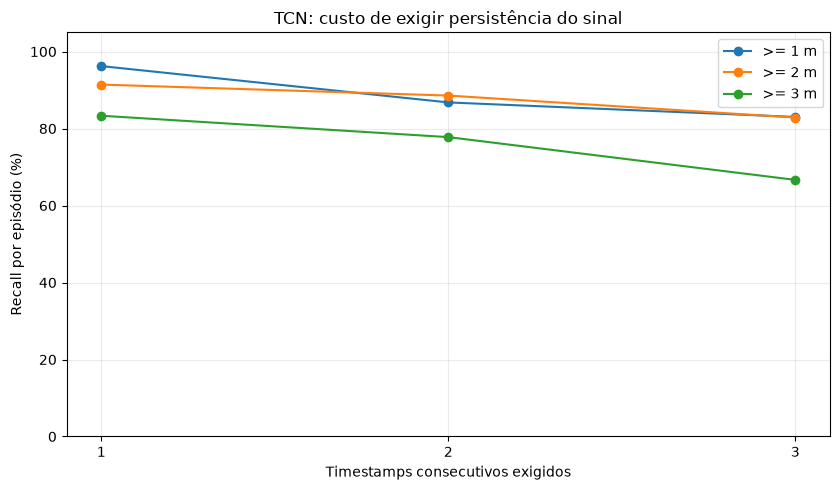

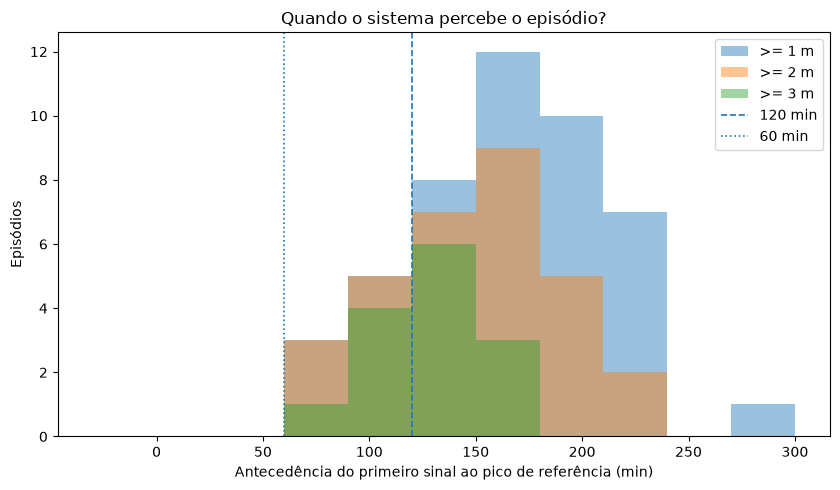

In [7]:
# Figura 1 - recall por episódio x persistência
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for sev in [1.0, 2.0, 3.0]:
    z = tcn_episode[tcn_episode["severity_threshold_m"] == sev].sort_values("min_consecutive")
    ax.plot(z["min_consecutive"], z["episode_recall_pct"], marker="o", label=f">= {sev:g} m")
ax.set_xlabel("Timestamps consecutivos exigidos")
ax.set_ylabel("Recall por episódio (%)")
ax.set_xticks([1,2,3])
ax.set_ylim(0, 105)
ax.grid(alpha=.25)
ax.legend()
ax.set_title("TCN: custo de exigir persistência do sinal")
fig.tight_layout()
fig.savefig(FIGURES / "v7_episode_recall_vs_persistence.png", dpi=170, bbox_inches="tight")
plt.show()

# Figura 2 - antecedência para o pico de referência, TCN com persistência escolhida
detail_path = TABLES / "operational_episode_details_2024_v7.csv"
detail = pd.read_csv(detail_path, parse_dates=["first_alert_time", "reference_peak_time"])
z = detail[(detail["min_consecutive"] == RECOMMENDED_PERSISTENCE) & (detail["detected"].astype(str).str.lower().isin(["true","1"]))].copy()
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for sev in [1.0,2.0,3.0]:
    q = z[z["threshold_m"] == sev]["lead_to_reference_peak_min"].dropna()
    if len(q):
        ax.hist(q, bins=np.arange(-30, 301, 30), alpha=.45, label=f">= {sev:g} m")
ax.axvline(120, linestyle="--", linewidth=1.2, label="120 min")
ax.axvline(60, linestyle=":", linewidth=1.2, label="60 min")
ax.set_xlabel("Antecedência do primeiro sinal ao pico de referência (min)")
ax.set_ylabel("Episódios")
ax.set_title("Quando o sistema percebe o episódio?")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "v7_episode_lead_time_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Congelando a arquitetura candidata antes de 2025

Este JSON é consumido pelo notebook `08`. Ele registra de forma auditável **o que será usado** e **por quê**.

A etapa ainda não usa cotas oficiais; portanto os sinais `>=1/2/3 m` devem ser descritos como **faixas de subida futura**, não como “atenção/alerta/emergência”.

In [8]:
architecture = {
    "version": "v7",
    "target_station": 413,
    "target_variable": "FLUm / nivel da estacao 413",
    "horizon_min": 120,
    "selection_period": "2024 development test",
    "official_stage_thresholds_used": False,
    "point_forecast": {
        "architecture": "hybrid_by_regime",
        "default_model": "xgboost_radar",
        "risk_model": "mean_tcn_gru",
        "regime_detector": "TCN p_ge_1m",
        "regime_probability_threshold": REGIME_THRESHOLD,
    },
    "severity_signals": {
        "model": "TCN",
        "thresholds_m": {
            "1.0": float(tcn_th.loc[1.0, "threshold"]),
            "2.0": float(tcn_th.loc[2.0, "threshold"]),
            "3.0": float(tcn_th.loc[3.0, "threshold"]),
        },
        "persistence_steps": int(RECOMMENDED_PERSISTENCE),
        "step_minutes": 10,
        "note": "Research severity signals for future rise; not official flood-stage alerts.",
    },
    "episode_evaluation": {
        "base_threshold_m": CONFIG.base_threshold_m,
        "gap_minutes": CONFIG.gap_minutes,
        "alert_gap_minutes": CONFIG.alert_gap_minutes,
        "reference_peak": "end of the 2 h window with maximum observed delta H within the episode",
    },
    "blind_2025_status": "LOCKED - run notebook 08 only after reviewing this file",
}
arch_path = MODELS / "architecture_candidate_v7.json"
arch_path.write_text(json.dumps(architecture, indent=2, ensure_ascii=False), encoding="utf-8")
print(arch_path)
print(json.dumps(architecture, indent=2, ensure_ascii=False))

C:\Users\osmar\Área de Trabalho\field-project\models\architecture_candidate_v7.json
{
  "version": "v7",
  "target_station": 413,
  "target_variable": "FLUm / nivel da estacao 413",
  "horizon_min": 120,
  "selection_period": "2024 development test",
  "official_stage_thresholds_used": false,
  "point_forecast": {
    "architecture": "hybrid_by_regime",
    "default_model": "xgboost_radar",
    "risk_model": "mean_tcn_gru",
    "regime_detector": "TCN p_ge_1m",
    "regime_probability_threshold": 0.8060694336891174
  },
  "severity_signals": {
    "model": "TCN",
    "thresholds_m": {
      "1.0": 0.8060694336891174,
      "2.0": 0.8210668563842773,
      "3.0": 0.8787392377853394
    },
    "persistence_steps": 2,
    "step_minutes": 10,
    "note": "Research severity signals for future rise; not official flood-stage alerts."
  },
  "episode_evaluation": {
    "base_threshold_m": 1.0,
    "gap_minutes": 60,
    "alert_gap_minutes": 30,
    "reference_peak": "end of the 2 h window with

## Conclusão desta etapa

A partir daqui o projeto tem **duas avaliações complementares**:

1. qualidade numérica a cada 10 minutos;
2. utilidade por episódio, com antecedência e falsos blocos de sinal.

Isso é mais próximo de um problema de early warning sem fingir que já conhecemos as cotas oficiais. O próximo notebook de relatório é `07d_relatorio_integrado_2024.ipynb`. **Não abra 2025 aqui.**